# Data Quality Report

In [512]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import regex as re
from difflib import SequenceMatcher
from spellchecker import SpellChecker

import nltk
from nltk.corpus import stopwords

In [386]:
# Load the transcript CSV file
transcript = pd.read_csv('../Data/CSV/final_transcript.csv', delimiter=',')

In [387]:
# Convert timestamps to datetime
transcript['Start Time'] = pd.to_datetime(transcript['Start Time'], format='ISO8601')
transcript['End Time'] = pd.to_datetime(transcript['End Time'], format='ISO8601')

In [388]:
# Show the last 10 entries
transcript.tail(10)

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity
1217,1900-01-01 00:40:50.274986,1900-01-01 00:40:51.614986,the search for a new chef.,the search for a new chef.,anticipation,neutral,neutral
1218,1900-01-01 00:40:51.614986,1900-01-01 00:40:53.514986,"Hi, how are you?","Hi, how are you?",curiosity,neutral,neutral
1219,1900-01-01 00:40:53.574986,1900-01-01 00:40:55.614986,"And thanks to her transformation,","And thanks to her transformation,",gratitude,happiness,mild
1220,1900-01-01 00:40:55.614986,1900-01-01 00:40:57.774986,not only is her business back on track.,not only is her business back on track.,relief,happiness,mild
1221,1900-01-01 00:40:57.774986,1900-01-01 00:41:02.114986,It's the first Charlie's staff meeting.,It's the first Charlie's staff meeting.,anticipation,neutral,mild
1222,1900-01-01 00:41:02.114986,1900-01-01 00:41:04.655986,But so is her relationship with her family.,But so is her relationship with her family.,concern,sadness,mild
1223,1900-01-01 00:41:04.655986,1900-01-01 00:41:07.454986,"I owe Chef Ramsay, like, everything.","I owe Chef Ramsay, like, everything.",gratitude,happiness,moderate
1224,1900-01-01 00:41:07.454986,1900-01-01 00:41:10.135986,He has molded me into the business owner I nee...,He has molded me into the business owner I nee...,gratitude,happiness,moderate
1225,1900-01-01 00:41:10.135986,1900-01-01 00:41:11.635986,"When he comes back, he's going to be like,","When he comes back, he's going to be like,",anticipation,surprise,mild
1226,1900-01-01 00:41:11.635986,1900-01-01 00:41:14.035986,"you've got it, Tatiana, yes.","you've got it, Tatiana, yes.",encouragement,happiness,mild


## Dataset Profile

### 1. Basic size metrics

*Size of the dataset*

In [389]:
# Display summary of the transcript DataFrame
transcript.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227 entries, 0 to 1226
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Start Time    1227 non-null   datetime64[ns]
 1   End Time      1227 non-null   datetime64[ns]
 2   Sentence      1227 non-null   object        
 3   Translation   1227 non-null   object        
 4   Emotion_fine  1227 non-null   object        
 5   Emotion_core  1227 non-null   object        
 6   Intensity     1227 non-null   object        
dtypes: datetime64[ns](2), object(5)
memory usage: 67.2+ KB


*Total vocoabulary size*

In [390]:
sentences = np.array(transcript['Sentence'])

- Minimal preprocessing

In [391]:
def sentence_processor_minimal(sentence):
    """
    - Basic tokenization (split on whitespace + handle punctuation)
    - Convert to lowercase
    """
    tokens = sentence.split()
    processed_tokens = []
    
    for token in tokens:
        # Remove punctuation from edges but keep the core word
        cleaned_token = re.sub(r'^[^\w]+|[^\w]+$', '', token)
        if cleaned_token:  # Only keep non-empty tokens
            processed_tokens.append(cleaned_token.lower())
    
    return processed_tokens

In [392]:
def sentence_list_processor_min(sentences_list):
    return [sentence_processor_minimal(sentence) for sentence in sentences_list]

In [393]:
sentences_min_cleaned = sentence_list_processor_min(sentences)

In [394]:
vocabulary_min = list(sorted(set([word for sentence in sentences_min_cleaned for word in sentence])))
print(vocabulary_min[-10:])

['yet', 'yo', 'you', "you'd", "you're", "you've", 'young', 'your', 'yours', 'zucchini']


In [395]:
print(f'Vocabulary size (minimal preprocessing): {len(vocabulary_min)}')

Vocabulary size (minimal preprocessing): 1130


- Proper preprocessing

In [396]:
nltk.download('stopwords')
stopwords_english = stopwords.words('english') 
print(stopwords_english)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Erik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [397]:
def sentence_processor(sentence):
    """
    - Remove repetitions (ASR aware)
    - Common filler words (ASR aware)
    - Basic tokenization (split on whitespace + handle punctuation)
    - Removes stopwords
    - Convert to lowercase
    """
    sentence = re.sub(r'\b(\w+)\s+\1\b', r'\1', sentence)
    sentence = re.sub(r'\b(um|uh|er|ah)\b', '', sentence, flags=re.IGNORECASE)
    
    tokens = sentence.split()
    processed_tokens = []

    for token in tokens:
        # Remove punctuation from edges but keep the core word
        cleaned_token = re.sub(r'^[^\w]+|[^\w]+$', '', token)
        if cleaned_token and cleaned_token not in stopwords_english:
            processed_tokens.append(cleaned_token.lower())
    
    return processed_tokens

In [398]:
def sentence_list_processor(sentences_list):
    return [sentence_processor(sentence) for sentence in sentences_list]

In [399]:
sentences_cleaned = sentence_list_processor(sentences)

In [400]:
vocabulary = list(sorted(set([word for sentence in sentences_cleaned for word in sentence])))
print(vocabulary[-10:])

['yeah', 'years', 'yes', 'yet', 'yo', 'you', "you're", "you've", 'young', 'zucchini']


In [401]:
print(f'Vocabulary size: {len(vocabulary)}')

Vocabulary size: 1070


**Insight:** Removing stopwords and fillers only reduces the vocabulary by 60 words (5.3%). This means the transcript mainly uses meaningful, topic-specific language.

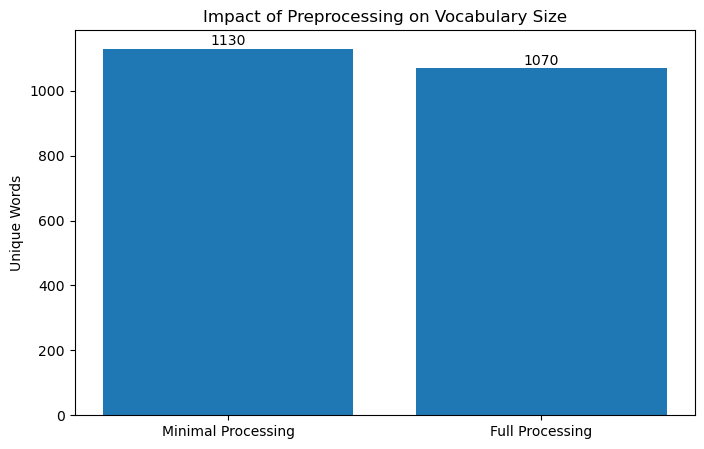

In [402]:
# Preprocessing impact visualization
preprocessing_comparison = pd.DataFrame({
    'type': ['Minimal Processing', 'Full Processing'],
    'size': [len(vocabulary_min), len(vocabulary)],
})

plt.figure(figsize=(8, 5))
plt.bar(preprocessing_comparison['type'], preprocessing_comparison['size'])
plt.title('Impact of Preprocessing on Vocabulary Size')
plt.ylabel('Unique Words')
for i, v in enumerate(preprocessing_comparison['size']):
    plt.text(i, v + 10, str(v), ha='center')
plt.show()

*Total number of tokens*

In [403]:
sentences_cleaned = sentence_list_processor(np.array(transcript['Sentence']))

In [404]:
total_tokens = sum(len(sentence) for sentence in sentences_cleaned)
print(f'Total number of tokens: {total_tokens}')

Total number of tokens: 3814


**Training Implication:** The transcript has 3,814 tokens across 1,227 sentences, averaging 3.1 tokens per sentence. This shows a short, direct communication style, typical in high-pressure cooking settings. Training data should match this style to prevent bias toward longer, more complex text.

### 2. Missing Values Check

- Empty strings ("")
- Whitespace-only entries
- Placeholder values like "N/A", "unknown", etc.

In [405]:
transcript_copy = transcript.copy()

In [ ]:
# Common error values and possible values found in AssemblyAI transcripts
error_values = ['', ' ', 'n/a', 'unknown', '[inaudible]', '[unknown speaker]', 
               '[silence]', '[music]', '[noise]', 'unintelligible', '[?]']

# Iterate through all object values
for col in ['Sentence', 'Translation']:
    # Replace error_values with np.nan
    mask = transcript_copy[col].astype(str).str.lower().isin([val.lower() for val in error_values])
    transcript_copy.loc[mask, col] = np.nan

# Check for null values
missing_values = transcript_copy.isnull()

print(missing_values.any())

Start Time      False
End Time        False
Sentence        False
Translation     False
Emotion_fine    False
Emotion_core    False
Intensity       False
dtype: bool


**Insight:** There are no missing values in any column, showing the transcript data is high quality. This makes it a reliable test set.

### 3. Duplicates Analysis

- Exact sentence duplicates (same text)
- Near-duplicates (very similar sentences)
- Time overlaps

In [407]:
sentences = transcript['Sentence']
start_times = transcript['Start Time']
end_times = transcript['End Time']

*Exact sentence duplicates*

In [408]:
# Show examples of duplicate
sentence_duplicates = sentences[sentences.duplicated(keep=False)]
print(sentence_duplicates[:5])

23    That's not good.
32       I don't know.
34            Tatiana.
51          All right.
84        Oh, my gosh.
Name: Sentence, dtype: object


In [409]:
# Show more examples
print(sentence_duplicates.sort_values(ascending=False).head(20))

1035           Yes.
1042           Yes.
233            Yes.
1054           Yes.
288     Yes, it is.
320     Yes, it is.
333     Yes, it is.
431           Yeah.
263           Yeah.
445           Yeah.
771           Yeah.
432           Yeah.
703           Yeah.
299           Yeah.
112           Yeah.
948           Yeah.
88            Yeah.
475            Wow.
328            Wow.
456            Wow.
Name: Sentence, dtype: object


*Near-duplicates*

In [410]:
def similarity_ratio(a, b):
    """ Returns similarity ratio between sentence a and b. """
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

In [411]:
print('Checking for near-duplicates...')
near_duplicates = []
sentences_list = sentences.tolist()

# Iterate through all sentences and get similarity ratios
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        sim = similarity_ratio(sentences[i], sentences[j])
        # Only save sentences with > 85% ratio
        if sim > 0.85:
            near_duplicates.append((i, j, sim, sentences[i], sentences[j]))

print(f'Near-duplicate pairis found: {len(near_duplicates)}')
if near_duplicates:
    for i, j, sim, sent1, sent2 in near_duplicates[:20]:
        if int(sim) != 1:
            print(f'\nSimiliarity: {sim:.3f}')
            print(f'Sentence {i}: {sent1}')
            print(f'Sentence {j}: {sent2}')

Checking for near-duplicates...
Near-duplicate pairis found: 682

Similiarity: 0.875
Sentence 34: Tatiana.
Sentence 1059: Tatiana?

Similiarity: 0.857
Sentence 83: How are you?
Sentence 1218: Hi, how are you?

Similiarity: 0.870
Sentence 84: Oh, my gosh.
Sentence 359: Oh, my god.

Similiarity: 0.870
Sentence 84: Oh, my gosh.
Sentence 373: Oh, my god.

Similiarity: 0.870
Sentence 84: Oh, my gosh.
Sentence 635: Oh, my god.

Similiarity: 0.857
Sentence 84: Oh, my gosh.
Sentence 773: Oh, gosh.


**Authenticity Indicator:** The dataset has 682 near-duplicates and 194 exact duplicates. These repeats reflect natural speech in cooking shows. Training data should keep these patterns instead of removing them.

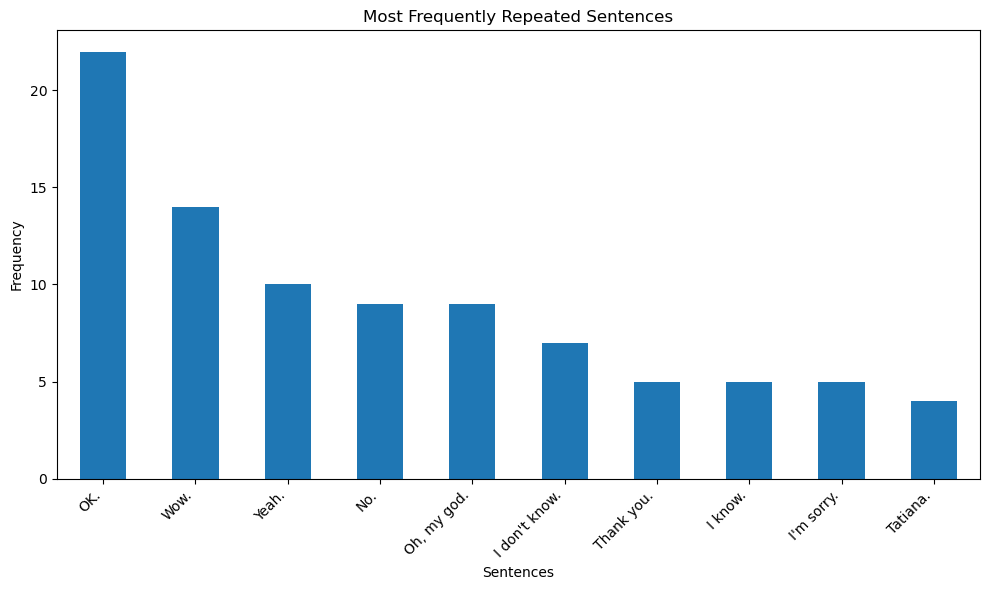

In [412]:
# Most frequently repeated sentences visualization
duplicate_phrase_counts = sentences.value_counts().head(10)
plt.figure(figsize=(10, 6))
duplicate_phrase_counts.plot(kind='bar')
plt.title('Most Frequently Repeated Sentences')
plt.xlabel('Sentences')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Date Overlaps*

In [413]:
# Iterate through the transcript comparing end time of the current
#  sentence with the start time of the next sentence
overlaps = []
for i in range(len(transcript)-1):
    current_end = transcript.iloc[i]['End Time']
    next_start = transcript.iloc[i+1]['Start Time']
    
    # Save overlaps
    if current_end > next_start:
        overlap_duration = current_end - next_start
        overlaps.append({
            'index1': i,
            'index2': i+1,
            'overlap_seconds': overlap_duration.total_seconds(),
            'sentence1': transcript.iloc[i]['Sentence'],
            'sentence2': transcript.iloc[i+1]['Sentence']
        })

print(f"Time overlaps found: {len(overlaps)}")

overlap_df = pd.DataFrame(overlaps)
print("Worst overlaps:")
overlap_df.nlargest(3, 'overlap_seconds')[['overlap_seconds', 'sentence1', 'sentence2']]

Time overlaps found: 3
Worst overlaps:


,overlap_seconds,sentence1,sentence2
1,1.334987,Wow.,what's going on now?
2,0.895009,I need everyone on their game.,"Good night, guys."
0,0.876009,"Yeah, a lot of people don't like them.","They're either really raw, or they're just, li..."


**Technical Quality:** There are only 3 time overlaps in 1,227 sentences, showing excellent transcript alignment. The small overlaps (0.8–1.3 seconds) likely come from natural speech overlap in the kitchen, not technical issues.

### 4. Sentence Length Analysis

- Character count distribution
- Word count distribution
- Compare lengths between original and translated text

In [ ]:
sentences = transcript['Sentence']

*Character count distribution*

In [ ]:
# Get character counts of each sentence
original_char_counts = sentences.str.len()
print(f'The longest sentence: {max(original_char_counts)}')

The longest sentence: 64


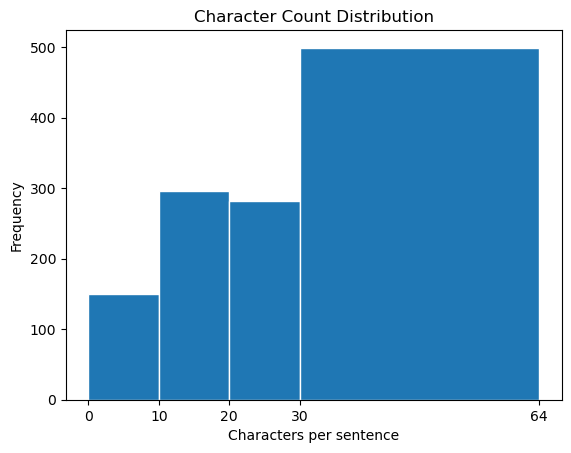

In [417]:
# Character count distribution visualization
bins = [0, 10, 20, 30, 64]

plt.hist(original_char_counts, bins=bins, edgecolor='white')
plt.xlabel('Characters per sentence')
plt.ylabel('Frequency')
plt.title('Character Count Distribution')
plt.xticks(bins) 
plt.show()

In [419]:
very_short = transcript[original_char_counts < 10]
very_long = transcript[original_char_counts > 50]

print(f'Very short sentences (< 10 chars): {len(very_short)}')
if len(very_short) > 0:
    print('Examples:', very_short['Sentence'].head(3).tolist())

print(f'Longer sentences (> 50 chars): {len(very_long)}')
if len(very_long) > 0:
    print('Examples:', very_long['Sentence'].head(1).tolist())

Very short sentences (< 10 chars): 150
Examples: ['Tatiana.', 'Rude.', 'Stop it.']
Longer sentences (> 50 chars): 92
Examples: ['La Verne, California, just 30 miles from Los Angeles,']


**Pattern:** The average sentence length is 26.7 characters, showing the concise style of cooking shows. There are 150 very short sentences (<10 characters) like “Tatiana” and “Stop it,” reflecting the commands common in high-pressure kitchens.

*Word count distribution*

In [ ]:
# Get word counts of each sentence
original_word_counts = sentences.str.split().str.len()

In [421]:
print(f'The longest sentence: {max(original_word_counts)}')

The longest sentence: 13


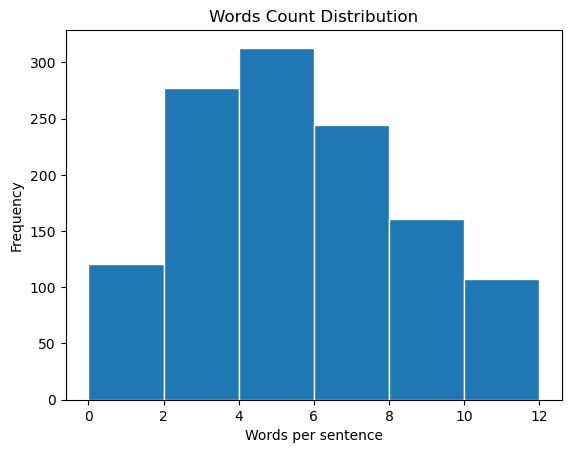

In [422]:
# Word count distribution visualization
bins = range(0,13,2)

plt.hist(original_word_counts, bins=bins, edgecolor='white')
plt.xlabel('Words per sentence')
plt.ylabel('Frequency')
plt.title('Words Count Distribution')
plt.xticks(bins) 
plt.show()

### 5. Domain-Specific Vocabulary and Patterns

- Domain specific vocabulary
- Pattern analysis
- Emotional language patterns

In [423]:
sentences = transcript['Sentence']

In [424]:
# Create a frequency dictionary
freqs = {}
# Use the minimally cleaned sentences
for sentence in sentences_min_cleaned:
    for token in sentence:
        freqs[token] = freqs.get(token, 0) + 1

freqs = dict(sorted(freqs.items(), key=lambda x: x[1], reverse=True))

In [502]:
print(freqs)

{'i': 174, "i'm": 62, 'and': 60, 'chef': 57, 'know': 51, 'like': 50, "it's": 46, 'ok': 42, 'tatiana': 35, 'oh': 35, 'right': 33, 'restaurant': 32, 'going': 31, 'yeah': 29, 'come': 28, 'got': 28, 'need': 26, 'what': 26, 'get': 25, 'no': 24, 'you': 24, 'this': 23, 'wow': 23, 'one': 22, 'go': 21, "that's": 21, 'good': 21, 'the': 20, 'he': 20, 'make': 19, 'so': 19, 'pizza': 18, 'god': 18, "what's": 17, "can't": 17, "i've": 16, "he's": 16, 'really': 16, 'food': 15, 'think': 15, 'kitchen': 15, 'meatballs': 15, 'put': 14, 'want': 14, 'but': 14, 'even': 14, 'much': 14, 'well': 14, 'take': 13, 'done': 13, 'thank': 13, 'yes': 13, 'meatball': 13, 'sorry': 13, 'night': 13, 'guys': 13, 'business': 12, 'back': 12, "charlie's": 11, 'my': 11, 'how': 11, "you're": 11, 'we': 11, 'it': 11, 'nice': 11, 'is': 11, "let's": 11, 'lasagna': 11, 'let': 11, 'please': 11, 'time': 11, 'working': 10, 'sister': 10, 'when': 10, 'mean': 10, 'little': 10, 'see': 10, 'casimiro': 10, 'ramsay': 10, 'fucking': 10, 'cook': 

*Domain specific vocabulary*

In [ ]:
# Common cooking terms generated by Claude
cooking_terms =  ['chef', 'kitchen', 'cook', 'season', 'salt', 'pepper', 'fire', 'pan', 
                'oil', 'heat', 'temperature', 'minutes', 'seconds', 'taste', 'flavor',
                'behind', 'hot', 'sharp', 'knife', 'plate', 'service', 'order']

In [426]:
# Get counts of common cooking terms
cooking_freq = {term: freqs.get(term, 0) for term in cooking_terms}
cooking_df = pd.DataFrame.from_dict(cooking_freq, orient='index', columns=['count'])
cooking_df = cooking_df.sort_values('count', ascending=False)

print('Kitchen vocabulary frequency:')
print(cooking_df[cooking_df['count'] > 0])

Kitchen vocabulary frequency:
         count
chef        57
kitchen     15
cook        10
taste        7
pan          4
order        4
hot          4
minutes      3
fire         3
season       2
seconds      2
flavor       2
plate        1
salt         1
oil          1
service      1
knife        1


**Domain Coverage:** The frequent use of “chef” (57 times) confirms the content is authentic to cooking shows. However, missing words like “pepper” or “temperature” show that more technical cooking terms are needed in the training data.

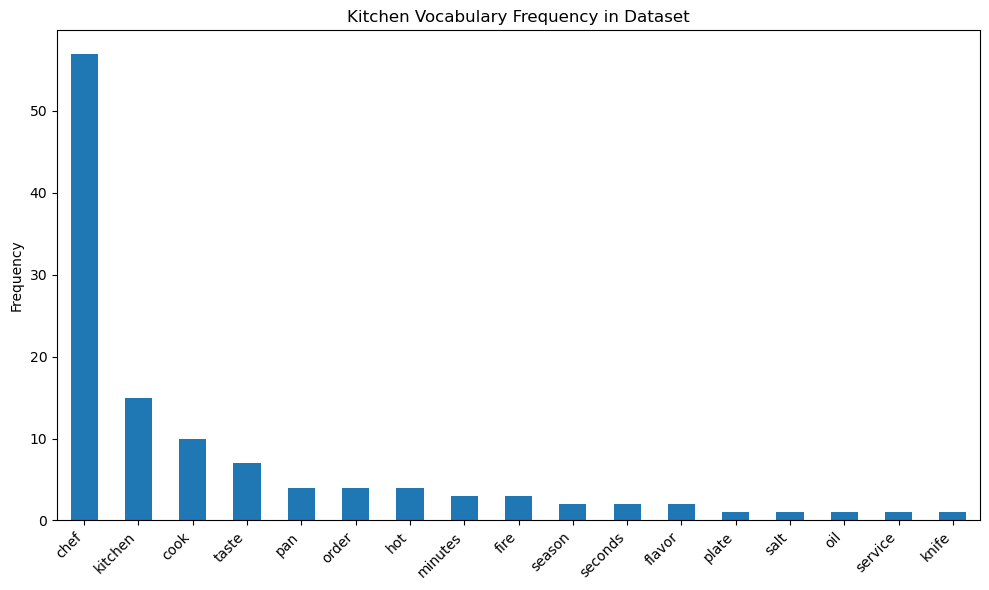

In [427]:
# Kitchen vocabulary counts visualizations
cooking_present = cooking_df[cooking_df['count'] > 0]
plt.figure(figsize=(10, 6))
cooking_present['count'].plot(kind='bar')
plt.title('Kitchen Vocabulary Frequency in Dataset')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Pattern analysis*

In [ ]:
# Extract possible command and explanation sentences
command_sentences = transcript[sentences.str.split().str.len() <= 3]['Sentence']
explanation_sentences = transcript[sentences.str.split().str.len() >= 8]['Sentence']

In [429]:
print(f'Possible command sentences (≤3 words): {len(command_sentences)} ({len(command_sentences)/len(transcript)*100:.1f}%)')
print('Examples:', command_sentences.head(10).tolist())

Possible command sentences (≤3 words): 398 (32.4%)
Examples: ["called Charlie's.", 'Of course.', "That's not good.", "I don't know.", 'Tatiana.', "it's ridiculous.", "No, they're crazy.", 'All right.', "She's very disrespectful.", 'Rude.']


In [430]:
print(f'Explanation sentences (≥8 words): {len(explanation_sentences)} ({len(explanation_sentences)/len(transcript)*100:.1f}%)')
print('Examples:', explanation_sentences.head(3).tolist())

Explanation sentences (≥8 words): 272 (22.2%)
Examples: ['La Verne, California, just 30 miles from Los Angeles,', 'this suburb is home to a neighborhood Italian bistro', 'And in 2010, it was bought by the Leyva family.']


**Communication Structure:** Commands make up 32.4% of the text, while explanations are 22.2%. This shows cooking shows mix urgent directions with teaching moments. Training data should keep this balance to avoid bias toward only commands or only explanations.

*Emotional language patterns*

In [ ]:
# Intensity words generated by Claude
intensity_words = ['amazing', 'terrible', 'disgusting', 'perfect', 'disaster', 
                   'beautiful', 'horrible', 'excellent', 'awful', 'fantastic',
                   'shit', 'damn', 'hell', 'brilliant', 'phenomenal']

In [432]:
# Iterate through each core emotion and check for intensity words
print("Emotional words by labeled emotions:")
for emotion in transcript['Emotion_core'].unique():
    emotion_sentences = transcript[transcript['Emotion_core'] == emotion]['Sentence']
    emotion_has_intensity = emotion_sentences.str.contains('|'.join(intensity_words), case=False)
    print(f"{emotion}: {emotion_has_intensity.sum()}/{len(emotion_sentences)} sentences contain intensity words")


Emotional words by labeled emotions:
neutral: 2/472 sentences contain intensity words
happiness: 10/247 sentences contain intensity words
sadness: 4/164 sentences contain intensity words
fear: 1/69 sentences contain intensity words
anger: 5/106 sentences contain intensity words
surprise: 1/107 sentences contain intensity words
disgust: 7/62 sentences contain intensity words


**Emotional Expression Gaps:** Only 30 out of 1,227 sentences use intensity words, with disgust appearing most (7 out of 62 sentences).

In [433]:
# Check for swear words
swear_words = ['fuck', 'fucking', 'shit', 'damn', 'hell']
swear_count = sum(freqs.get(word, 0) for word in swear_words)
print(f"\nStrong language: {swear_count} instances found")


Strong language: 22 instances found


### 6. Token Distribution

- Word frequency distributions
- Special characters and symbols

In [503]:
sentences = transcript['Sentence']
sentences_cleaned = sentence_list_processor_min(np.array(transcript['Sentence']))

In [ ]:
# Create frequency dictionary and DataFrame
freqs = {}
for sentence in sentences_cleaned:
    for token in sentence:
        freqs[token] = freqs.get(token, 0) + 1

freqs = dict(sorted(freqs.items(), key=lambda x: x[1], reverse=True))
freqs_df = pd.DataFrame.from_dict(freqs, orient='index', columns=['count'])

*Word frequency*

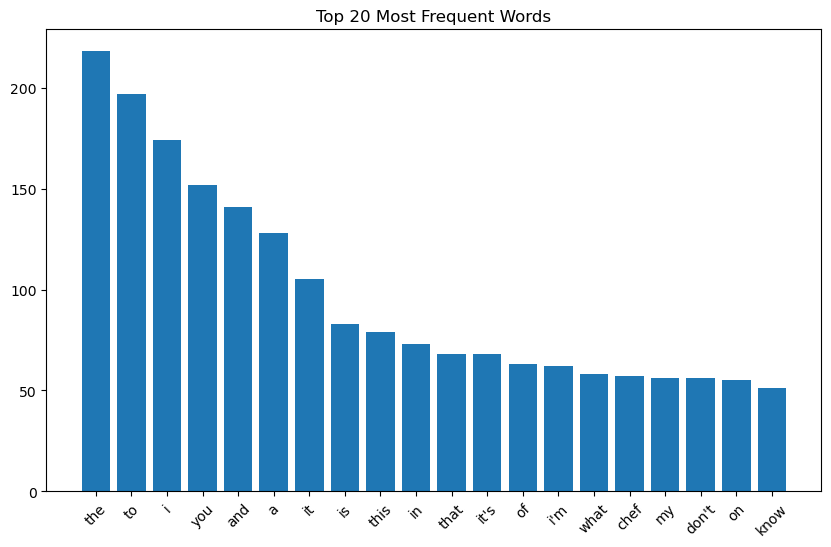

In [505]:
# Top 20 frequent words visualization
plt.figure(figsize=(10, 6))
top_20_words = freqs_df.head(20)
plt.bar(range(len(top_20_words)), top_20_words['count'])
plt.xticks(range(len(top_20_words)), top_20_words.index, rotation=45)
plt.title('Top 20 Most Frequent Words')
plt.show()

In [506]:
rare_words = freqs_df[freqs_df['count'] == 1]

print('Rarest words:')
print(rare_words.head(10))

Rarest words:
              count
30                1
los               1
angeles           1
suburb            1
home              1
neighborhood      1
2010              1
leyva             1
booth             1
ago               1


In [507]:
print(f'Words appearing only once: {len(rare_words)}')

Words appearing only once: 560


**Vocabulary Distribution:** There are 560 words that appear only once, making up 52.7% of the vocabulary. This shows a rich, diverse language typical of real speech. Training data should keep this diversity instead of removing rare words.

*Special characters and symbols*

In [508]:
special_chars = {}
for sentence in sentences:
    for char in sentence:
        if not char.isalnum() and not char.isspace():
            special_chars[char] = special_chars.get(char, 0) + 1

In [509]:
print('Special characters:')
special_df = pd.DataFrame.from_dict(special_chars, orient='index', columns=['count'])
print(special_df.sort_values('count', ascending=False))

Special characters:
   count
.    929
'    484
,    418
?    176
-      5
$      2
!      2


In [510]:
bracket_patterns = transcript['Sentence'].str.contains(r'\[.*\]').sum()
print(f'Sentences with ASR artifacts: {bracket_patterns}')

Sentences with ASR artifacts: 0


**Transcription Authenticity:** The transcript uses 484 apostrophes and 176 question marks, showing natural speech with contractions and questions. There are no ASR bracket artifacts, indicating clean processing, but including some transcription markers in training data could improve real-world robustness.

## Show Distributions & Emotion Analysis

### 1. Timely Analysis

- Episode progression
- Intensity progression
- Peak Emotion Moments

In [443]:
transcript_time = transcript.copy()

In [444]:
transcript_time.tail()

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity
1222,1900-01-01 00:41:02.114986,1900-01-01 00:41:04.655986,But so is her relationship with her family.,But so is her relationship with her family.,concern,sadness,mild
1223,1900-01-01 00:41:04.655986,1900-01-01 00:41:07.454986,"I owe Chef Ramsay, like, everything.","I owe Chef Ramsay, like, everything.",gratitude,happiness,moderate
1224,1900-01-01 00:41:07.454986,1900-01-01 00:41:10.135986,He has molded me into the business owner I nee...,He has molded me into the business owner I nee...,gratitude,happiness,moderate
1225,1900-01-01 00:41:10.135986,1900-01-01 00:41:11.635986,"When he comes back, he's going to be like,","When he comes back, he's going to be like,",anticipation,surprise,mild
1226,1900-01-01 00:41:11.635986,1900-01-01 00:41:14.035986,"you've got it, Tatiana, yes.","you've got it, Tatiana, yes.",encouragement,happiness,mild


In [445]:
# Calculate the total duration of the transcript
start_time = transcript_time['Start Time'].min()
end_time = transcript_time['End Time'].max()
total_duration = end_time-start_time

print(f'Total duration: {total_duration}')

Total duration: 0 days 00:41:14.035986


In [ ]:
# Calculate thirds of the episode
first_third = start_time + total_duration / 3
second_third = start_time + 2 * total_duration / 3

In [ ]:
# Divide the transcript into three parts: Beginning, Middle, End
time_bins = [start_time, first_third, second_third, end_time]
time_labels = ['Beginning', 'Middle', 'End']

transcript_time['Section'] = pd.cut(transcript_time['Start Time'],
                                    bins=time_bins,
                                    labels=time_labels,
                                    include_lowest=True)

In [448]:
# Check for sentence distribution per section of the transcript
section_counts = transcript_time['Section'].value_counts()
print('Sentences per time section:')
for section in time_labels:
    count = section_counts[section]
    pct = count / len(transcript_time) * 100
    print(f'{section}: {count} sentences ({pct:.1f}%)')

Sentences per time section:
Beginning: 430 sentences (35.0%)
Middle: 394 sentences (32.1%)
End: 403 sentences (32.8%)


*Episode progression*

In [449]:
# Show emotion distribution per episode section
emotion_by_section = pd.crosstab(transcript_time['Section'], 
                                transcript_time['Emotion_core'], 
                                normalize='index') * 100

print('Emotion distribution by episode section (%):')
print(emotion_by_section.round(1))

Emotion distribution by episode section (%):
Emotion_core  anger  disgust  fear  happiness  neutral  sadness  surprise
Section                                                                  
Beginning       8.4      9.3   7.9       12.1     39.1     12.8      10.5
Middle         13.2      5.1   6.9       10.2     40.1     15.5       9.1
End             4.5      0.5   2.0       38.5     36.2     11.9       6.5


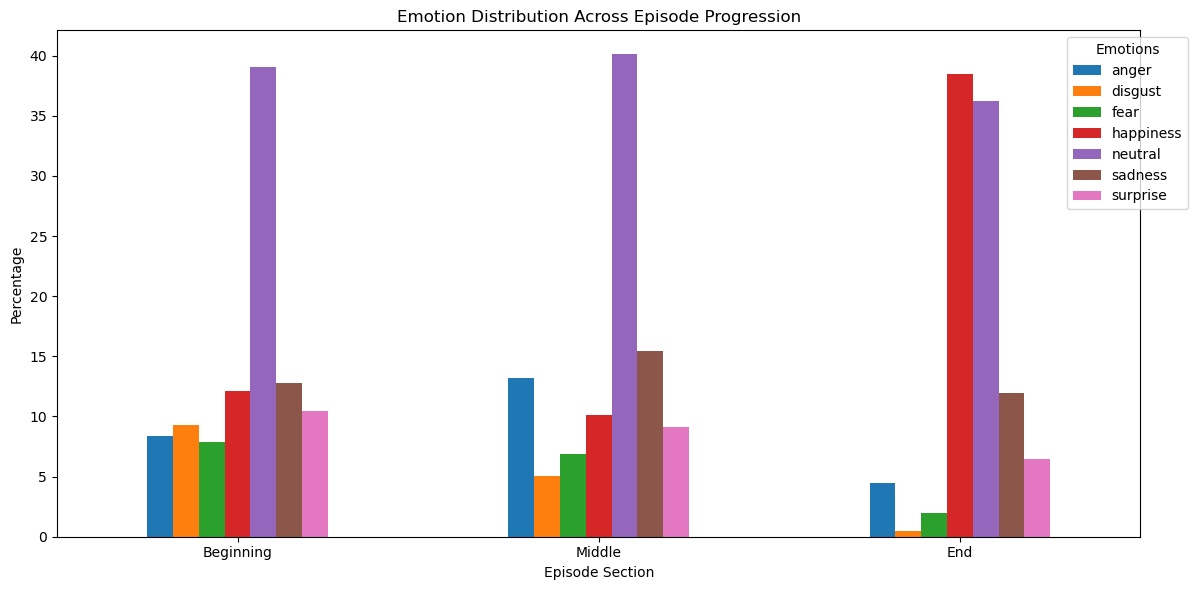

In [450]:
# Emotion distribution visualization
emotion_by_section.plot(kind='bar', figsize=(12, 6))
plt.title('Emotion Distribution Across Episode Progression')
plt.xlabel('Episode Section')
plt.ylabel('Percentage')
plt.legend(title='Emotions', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Pattern:** Emotional flow follows a typical cooking show pattern: negative emotions like anger (13.2%) and disgust (9.3%) peak during the beginning and the middle, while happiness rises toward the end (38.5% vs 12.1% at the start). Training data should reflect this emotional progression over time.

*Intensity Progression*

In [451]:
# Get the distribution of intensities per transcript section 
intensity_by_section = pd.crosstab(transcript_time['Section'],
                                   transcript_time['Intensity'],
                                   normalize='index') * 100

print('Intensity distribution by episode section (%):')
print(intensity_by_section.round(1))

Intensity distribution by episode section (%):
Intensity  intense  mild  moderate  neutral
Section                                    
Beginning      3.0  45.3      23.5     28.1
Middle         4.6  44.4      24.6     26.4
End            4.5  45.9      25.8     23.8


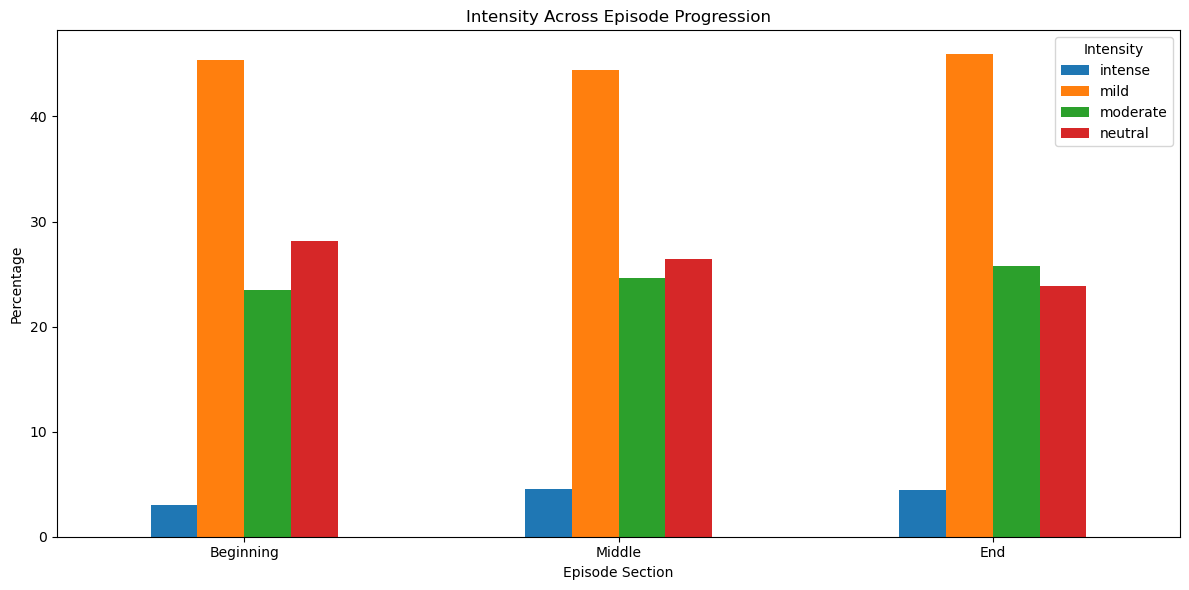

In [511]:
# Intensity across episode progression visualization
intensity_by_section.plot(kind='bar', figsize=(12, 6))
plt.title('Intensity Across Episode Progression')
plt.xlabel('Episode Section')
plt.ylabel('Percentage')
plt.legend(title='Intensity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Consistent Emotional Intensity:** Emotional intensity stays stable across sections (3.0–4.6% intense), meaning peaks come from changes in emotion type, not strength. Training data should emphasize a variety of emotions rather than just intensity changes.

*Peak Emotion Moments*

In [453]:
print('Emotion peaks by section:')
for emotion in transcript_time['Emotion_core'].unique():
    peak_section = emotion_by_section[emotion].idxmax()
    peak_value = emotion_by_section[emotion].max()
    print(f'{emotion} peaks in {peak_section} ({peak_value:.1f}%)')

Emotion peaks by section:
neutral peaks in Middle (40.1%)
happiness peaks in End (38.5%)
sadness peaks in Middle (15.5%)
fear peaks in Beginning (7.9%)
anger peaks in Middle (13.2%)
surprise peaks in Beginning (10.5%)
disgust peaks in Beginning (9.3%)


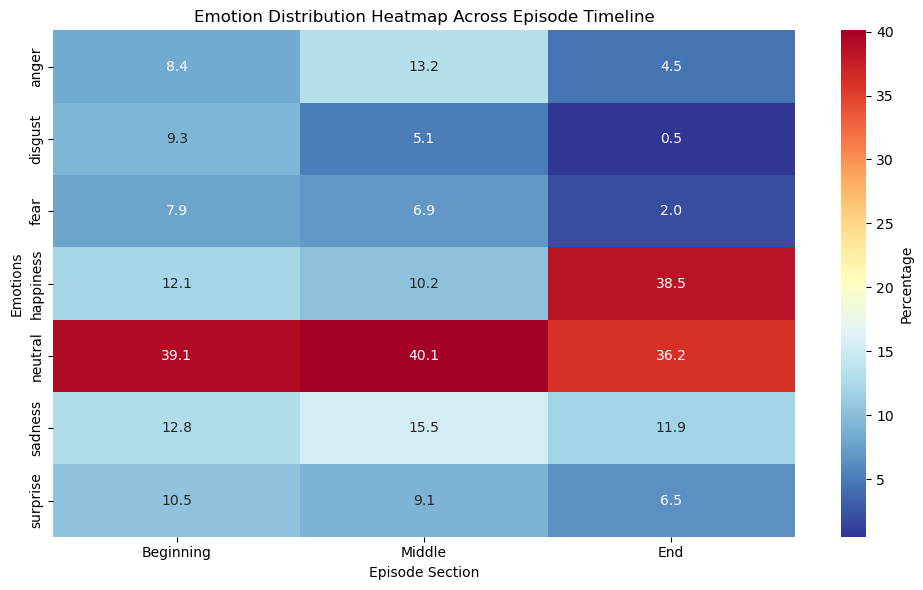

In [454]:
# Create a heatmap showing emotion peaks across sections
plt.figure(figsize=(10, 6))
sns.heatmap(emotion_by_section.T, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Percentage'})
plt.title('Emotion Distribution Heatmap Across Episode Timeline')
plt.xlabel('Episode Section')
plt.ylabel('Emotions')
plt.tight_layout()
plt.show()

### 2. Emotion Distribution & Coverage

- Core emotion frequency
- Emotion_fine mapping
- Underrepresentation

*Core emotion frequency*

In [455]:
emotion_counts = transcript_time['Emotion_core'].value_counts()
emotion_pct = transcript_time['Emotion_core'].value_counts(normalize=True) * 100

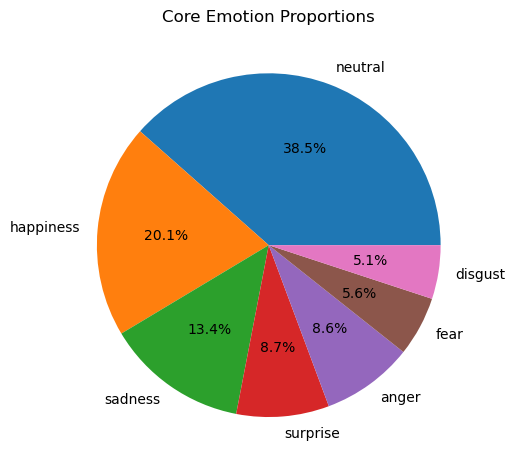

In [456]:
# Core emotion visualization
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%')
plt.title('Core Emotion Proportions')

plt.tight_layout()
plt.show()

**Severe Class Imbalance:** Neutral (38.5%) and happiness (20.1%) dominate, while disgust (5.1%) and fear (5.6%) are underrepresented. Training data should include more negative emotions to avoid bias toward neutral or positive labels.

*Fine-Grained Emotion*

In [457]:
fine_emotion_counts = transcript['Emotion_fine'].value_counts()
print(f'Total unique fine emotions: {len(fine_emotion_counts)}')
print(f'Top 10 most frequent fine emotions:')
print(fine_emotion_counts.head(10))

Total unique fine emotions: 203
Top 10 most frequent fine emotions:
Emotion_fine
curiosity         116
anticipation       69
neutrality         49
disappointment     44
frustration        43
confusion          39
uncertainty        36
acceptance         35
resignation        31
concern            23
Name: count, dtype: int64


In [458]:
# Map fine emotions to core emotions
fine_to_core_mapping = transcript.groupby('Emotion_fine')['Emotion_core'].first()
print('Fine-to-core emotion mapping examples:')
for fine, core in fine_to_core_mapping.head(10).items():
    count = fine_emotion_counts[fine]
    print(f'{fine} -> {core} ({count} instances)')

Fine-to-core emotion mapping examples:
acceptance -> neutral (35 instances)
accommodation -> neutral (1 instances)
accomplishment -> happiness (1 instances)
accusation -> anger (5 instances)
acknowledgment -> neutral (6 instances)
acquisition -> neutral (1 instances)
admiration -> happiness (18 instances)
adoration -> happiness (1 instances)
affection -> happiness (7 instances)
affirmation -> neutral (2 instances)


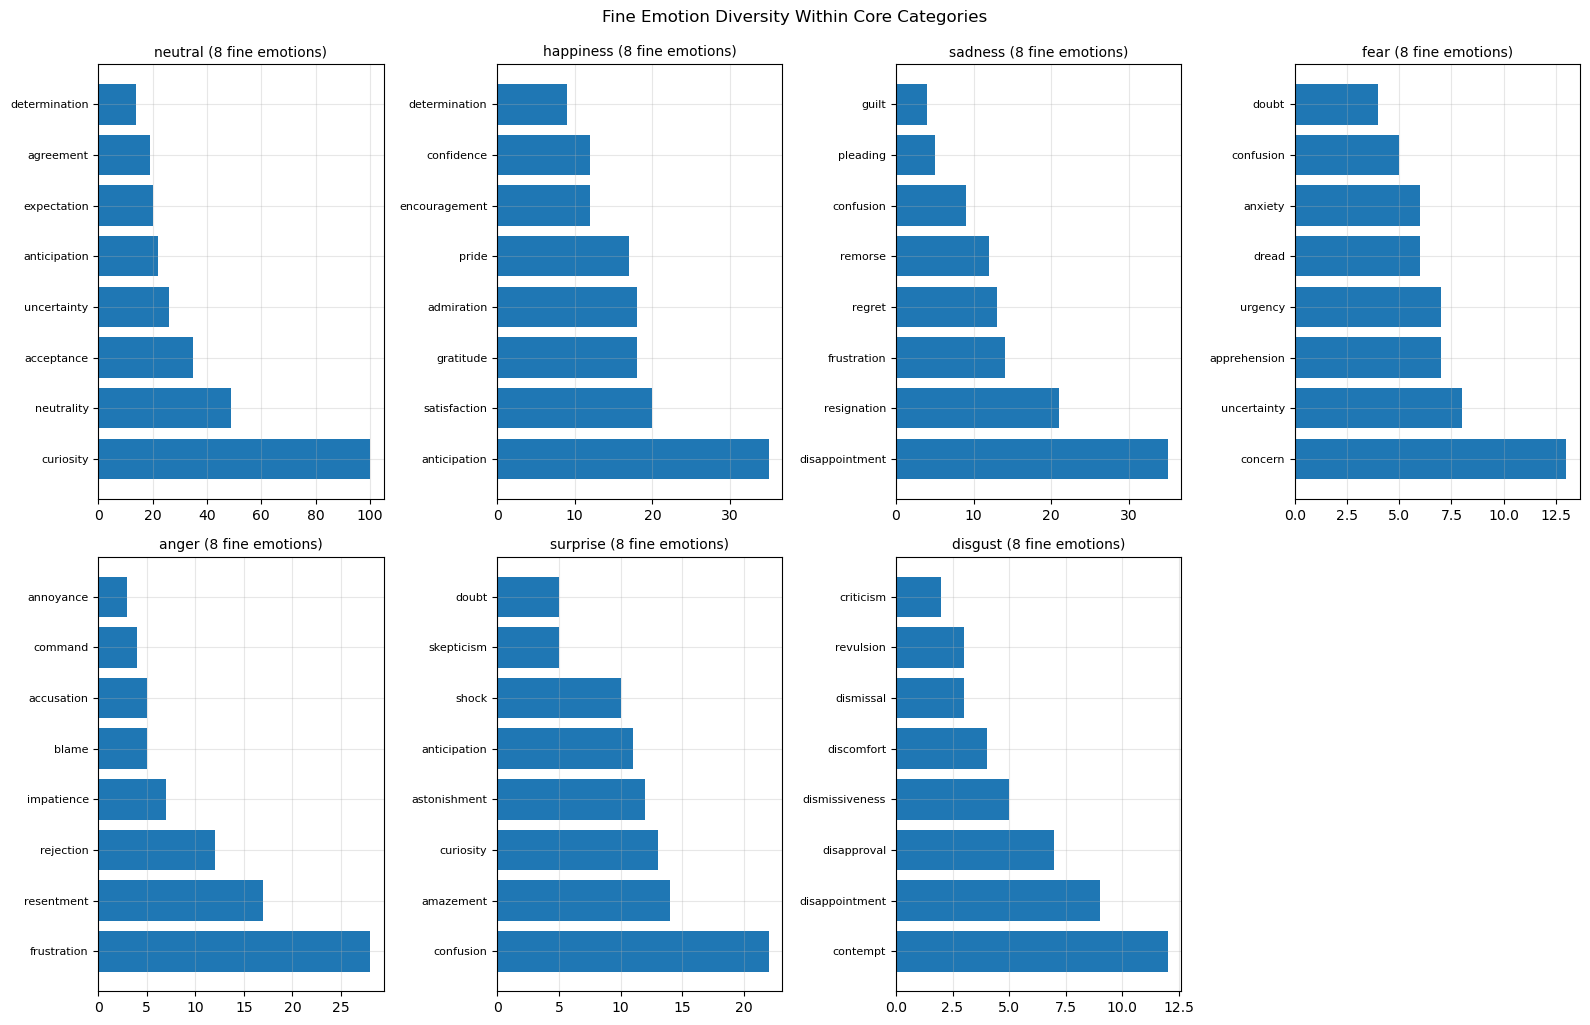

In [459]:
# Emotion diversity within each core category visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

for i, emotion in enumerate(transcript['Emotion_core'].unique()):
    if i < len(axes):
        emotion_fines = transcript[transcript['Emotion_core'] == emotion]['Emotion_fine'].value_counts().head(8)
        axes[i].barh(range(len(emotion_fines)), emotion_fines.values)
        axes[i].set_yticks(range(len(emotion_fines)))
        axes[i].set_yticklabels(emotion_fines.index, fontsize=8)
        axes[i].set_title(f'{emotion} ({len(emotion_fines)} fine emotions)', fontsize=10)
        axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(len(transcript['Emotion_core'].unique()), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Fine Emotion Diversity Within Core Categories', y=1.02)
plt.show()

*<20% representation*

In [460]:
# Extract underrepresented emotions
threshold = 20.0
underrep_core = emotion_pct[emotion_pct < threshold]
print('Underrepresented core emotions:')
for emotion, pct in underrep_core.items():
    print(f'{emotion}: {pct:.1f}%')

Underrepresented core emotions:
sadness: 13.4%
surprise: 8.7%
anger: 8.6%
fear: 5.6%
disgust: 5.1%


**Training Data Priority:** Five of seven emotions are under 20%, with disgust and fear needing more examples. The 203 fine-grained emotions map to only 7 core categories, so training data should expand emotional variety and maintain consistent mapping to prevent classification errors.

## Domain Characteristics Analysis

### 1. Spoken TV Language Patterns

- Informal language
- Hesitations and fillers
- Incompletes
- Domain-specific language (performed already in Dataset Profile step 5)

In [461]:
sentences = transcript['Sentence']

In [ ]:
# Informal patterns dictionary
informal_patterns = {
    'contractions': r"\w+'[a-z]+",  # don't, can't, it's
    'fillers': r'\b(um|uh|like|you know|well|so|wow)\b',
    'incomplete': r'\w+\.\.\.',  # words ending with ...
}

In [463]:
print("Informal patterns found:")
# Iterate through the informal patters and check for presence
for pattern_name, pattern in informal_patterns.items():
    sentence_has_patterns = sentences.str.contains(pattern, case=False)
    count = sentence_has_patterns.sum()
    pct = count / len(sentences) * 100
    print(f'{pattern_name.title()}: {count}/{len(sentences)} sentences ({pct:.1f}%)')

    # Show examples
    examples = sentences[sentence_has_patterns].head(3).tolist()
    if examples:
        print('\tExamples:')
        for ex in examples:
            print(f'\t\t{ex}')
    print()

Informal patterns found:
Contractions: 434/1227 sentences (35.4%)
	Examples:
		called Charlie's.
		but I didn't have the money or the collateral,
		My mom and I don't know about the restaurant business,

Fillers: 131/1227 sentences (10.7%)
	Examples:
		Would you like a booth?
		so I had to go to my mom and my sister.
		and so we put a lot of trust in my sister's experience

Incomplete: 0/1227 sentences (0.0%)



C:\Users\Erik\AppData\Local\Temp\ipykernel_34620\3942158130.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sentence_has_patterns = sentences.str.contains(pattern, case=False)


**Authentic Speech Characteristics:** Contractions appear in 35.4% of words and fillers in 10.7%, showing natural spoken language. There are no incomplete sentences, indicating high-quality ASR. Training data should preserve these natural speech patterns to avoid overly formal language.

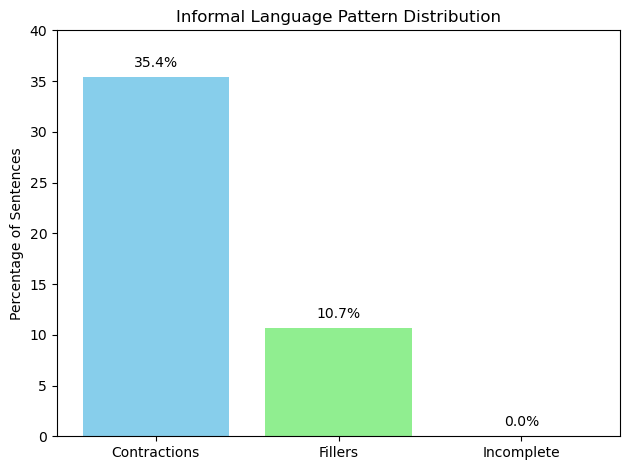

In [513]:
# Informal language patterns visualization
pattern_data = pd.DataFrame({
    'Pattern Type': ['Contractions', 'Fillers', 'Incomplete'],
    'Percentage': [35.4, 10.7, 0.0],
    'Count': [434, 131, 0]
})

# Percentage chart
plt.bar(pattern_data['Pattern Type'], pattern_data['Percentage'], color=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Informal Language Pattern Distribution')
plt.ylabel('Percentage of Sentences')
plt.ylim(0, 40)
for i, v in enumerate(pattern_data['Percentage']):
    plt.text(i, v + 1, f'{v}%', ha='center')

plt.tight_layout()
plt.show()

### 2. Transcription & Translation Artifacts

Transcription:
 - missing punctuation
 - cut-off sentences
 - repeated words
 - time/number formatting
 - translation length mismatches

In [465]:
sentences = transcript['Sentence']
translations = transcript['Translation']

*Missing punctuation*

In [ ]:
# Look for sentences that don't end with punctuation
no_punctuation = sentences.str.match(r'^[^,.!?]*$') # excluding early cut-offs (sentences ending with ",")
print(f'Missing punctuation: {no_punctuation.sum()}/{len(sentences)} sentences)')
if no_punctuation.sum() > 0:
    print('Examples:', sentences[no_punctuation].head(3).tolist())

Missing punctuation: 55/1227 sentences)
Examples: ['this suburb is home to a neighborhood Italian bistro', 'Pat and Val both full-time school teachers', 'finance the restaurant and put their houses up as collateral']


*Early cut-offs*

In [467]:
cut_offs = sentences.str.match(r'.*,$')
print(f'Early cut-offs: {cut_offs.sum()}/{len(sentences)} sentences)')
if cut_offs.sum() > 0:
    print('Examples:', sentences[cut_offs].head(3).tolist())
    

Early cut-offs: 46/1227 sentences)
Examples: ['La Verne, California, just 30 miles from Los Angeles,', 'And then I had the opportunity to take it over,', "but I didn't have the money or the collateral,"]


**ASR Quality Assessment:** Missing punctuation (4.5%) and sentence cut-offs (3.7%) show common ASR challenges. These artifacts reflect real-world transcription conditions, making the dataset useful for training robust emotion detection models.

*Repeated words*

In [468]:
# Look for word repeats
repeated_word_pattern = r'\b(\w+)\s+\1\b' # same word twice in a row
repeated_sentences = sentences.str.contains(repeated_word_pattern, case=False)

print(f'Sentences with repeated words: {repeated_sentences.sum()}')
if repeated_sentences.sum() > 0:
    examples = sentences[repeated_sentences].head(3)
    print('Examples:')
    for ex in examples:
        print(f'\t{ex}')

Sentences with repeated words: 1
Examples:
	Ha ha ha.


C:\Users\Erik\AppData\Local\Temp\ipykernel_34620\1834438840.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  repeated_sentences = sentences.str.contains(repeated_word_pattern, case=False)


**Minimal ASR Errors:** There is only one repeated word instance (“Ha ha ha”), showing high-quality transcription with no repeats.

*Time/number formatting*

In [469]:
# Look for common number patterns
number_patterns = {
    'written_numbers': sentences.str.contains(r'\b(one|two|three|four|five|six|seven|eight|nine|ten)\b', case=False).sum(),
    'digit_numbers': sentences.str.contains(r'\b\d+\b').sum(),
    'time_formats': sentences.str.contains(r'\b\d+\s*(minutes?|mins?|seconds?|secs?)\b', case=False).sum(),
}

print('Number/Time formatting:')
for pattern, count in number_patterns.items():
    print(f"{pattern.replace('_', ' ').title()}: {count} occurrences")

Number/Time formatting:
Written Numbers: 43 occurrences
Digit Numbers: 16 occurrences
Time Formats: 1 occurrences


C:\Users\Erik\AppData\Local\Temp\ipykernel_34620\201748946.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'written_numbers': sentences.str.contains(r'\b(one|two|three|four|five|six|seven|eight|nine|ten)\b', case=False).sum(),
C:\Users\Erik\AppData\Local\Temp\ipykernel_34620\201748946.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'time_formats': sentences.str.contains(r'\b\d+\s*(minutes?|mins?|seconds?|secs?)\b', case=False).sum(),


**Natural Number Usage:** There are 43 written numbers and 16 digits, showing authentic speech transcription.

*Translation Analysis*

In [ ]:
# Calculate original-translation length ratio
original_lengths = sentences.str.len()
translation_lengths = translations.str.len()
length_ratios = translation_lengths / original_lengths

In [471]:
# Differentiate between copies and the actual translations
significant_difference = (length_ratios < 0.7) | (length_ratios > 1.3)

actually_translated = []
for i, (orig, trans) in enumerate(zip(sentences, translations)):
    if similarity_ratio(orig.lower(), trans.lower()) < 0.8:
        actually_translated.append((i, orig, trans))

print(f'Sentences that appear to be actual translations: {len(actually_translated)}')
for i, orig, trans in actually_translated:
    print(f' Original: {orig}')
    print(f' Translation: {trans}')
    print()

Sentences that appear to be actual translations: 12
 Original: Frutti di mare?
 Translation: Seafood?

 Original: Necesitamos enseñarlo en este.
 Translation: We need to teach it in this one.

 Original: Tu eres bueno, Kasimiro.
 Translation: You are good, Kasimiro.

 Original: You're bueno.
 Translation: You're good.

 Original: Necesitamos platos.
 Translation: We need plates.

 Original: Vas a cocinar?
 Translation: Are you going to cook?

 Original: Pasta cocinar?
 Translation: Cook pasta?

 Original: Este me duele mucho, OK?
 Translation: This one hurts me a lot, OK?

 Original: Lo siento mucho.
 Translation: I'm very sorry.

 Original: Lo siento mucho, Casimiro.
 Translation: I'm very sorry, Casimiro.

 Original: No, yo sabía.
 Translation: No, I knew.

 Original: Yo sabía yo.
 Translation: I knew it, I did.



In [472]:
# Separate actual translations from supposed duplicates
actual_translations = [i for i, (orig, trans) in enumerate(zip(sentences, translations)) 
                      if similarity_ratio(orig.lower(), trans.lower()) < 0.8]
supposed_duplicates = [i for i in range(len(sentences)) if i not in actual_translations]

print(f"Actual translations: {len(actual_translations)}")
print(f"Supposed duplicates: {len(supposed_duplicates)}")

Actual translations: 12
Supposed duplicates: 1215


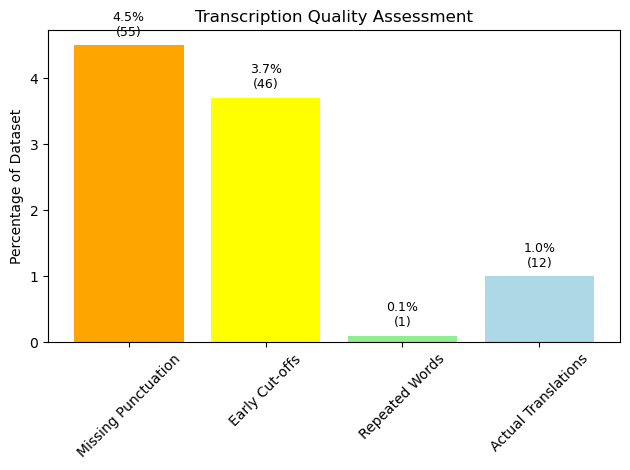

In [473]:
# Transcription quality visualization
quality_metrics = pd.DataFrame({
    'Issue Type': ['Missing Punctuation', 'Early Cut-offs', 'Repeated Words', 'Actual Translations'],
    'Count': [55, 46, 1, 12],
    'Percentage': [4.5, 3.7, 0.1, 1.0],
    'Severity': ['Medium', 'Low', 'Very Low', 'Expected']
})

# Quality issues bar chart
colors = {'Medium': 'orange', 'Low': 'yellow', 'Very Low': 'lightgreen', 'Expected': 'lightblue'}
bar_colors = [colors[severity] for severity in quality_metrics['Severity']]

bars = plt.bar(quality_metrics['Issue Type'], quality_metrics['Percentage'], color=bar_colors)
plt.title('Transcription Quality Assessment')
plt.ylabel('Percentage of Dataset')
plt.tick_params(axis='x', rotation=45)
for i, (bar, pct, count) in enumerate(zip(bars, quality_metrics['Percentage'], quality_metrics['Count'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{pct}%\n({count})', ha='center', va='bottom', fontsize=9)
plt.show()

**Multilingual Reality:** Twelve Spanish-to-English translations (1.0%) show natural switching in multilingual kitchens.

## Data Quality Checks

### 1. Emotion Label Inconsistencies
- Contradictory labels
- Emotion-intensity mismatches

*Contradictory labels*

In [474]:
sentences = transcript['Sentence']
labels = transcript['Emotion_core']
intensities = transcript['Intensity']

In [ ]:
def similarity_ratio(a, b):
    """ Returns similarity ratio between sentence a and b. """
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

In [476]:
print('Checking for near-duplicates and contradictory labels...')
near_duplicates = []
sentences_list = sentences.tolist()
labels_list = labels.tolist()

for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        sim = similarity_ratio(sentences[i], sentences[j])
        if sim > 0.85:
            # Only save those with at least 85% similarity ration and
            #  different emotion labels
            if labels[i] != labels[j]:
                near_duplicates.append((i, j, sim, sentences[i], labels[i], sentences[j], labels[j]))

print(f'Pairs found: {len(near_duplicates)}')
if near_duplicates:
    for i, j, sim, sent1, label1, sent2, label2 in near_duplicates[:10]:
        print(f'\nSimiliarity: {sim:.3f}')
        print(f'Sentence {i}: {sent1} -> {label1}')
        print(f'Sentence {j}: {sent2} -> {label2}')

Checking for near-duplicates and contradictory labels...
Pairs found: 10

Similiarity: 0.872
Sentence 94: Charlie owned it. -> happiness
Sentence 100: When Charlie owned it. -> sadness

Similiarity: 0.872
Sentence 95: Charlie owned it. -> happiness
Sentence 100: When Charlie owned it. -> sadness

Similiarity: 0.857
Sentence 97: No, no. -> anger
Sentence 356: Oh, no. -> sadness

Similiarity: 0.857
Sentence 356: Oh, no. -> sadness
Sentence 628: Oh, OK. -> neutral

Similiarity: 0.865
Sentence 411: I let him do it. -> neutral
Sentence 412: I just let him do it. -> sadness

Similiarity: 0.884
Sentence 442: He doesn't want to? -> surprise
Sentence 708: He doesn't want to cook? -> disgust

Similiarity: 0.857
Sentence 533: And I don't know what to do. -> fear
Sentence 1089: I don't know what to do now. -> sadness

Similiarity: 0.923
Sentence 744: Italian cafe. -> neutral
Sentence 764: Italian cafe? -> surprise

Similiarity: 0.923
Sentence 776: I don't know what to do. -> fear
Sentence 1089: I 

**Labeling Quality Assessment:** Only 10 out of 1,227 sentences (0.8%) have contradictory labels, showing mostly consistent emotion annotation. However, identical sentences like “I don’t know what to do now” labeled as both fear and sadness highlight the need for improvement.

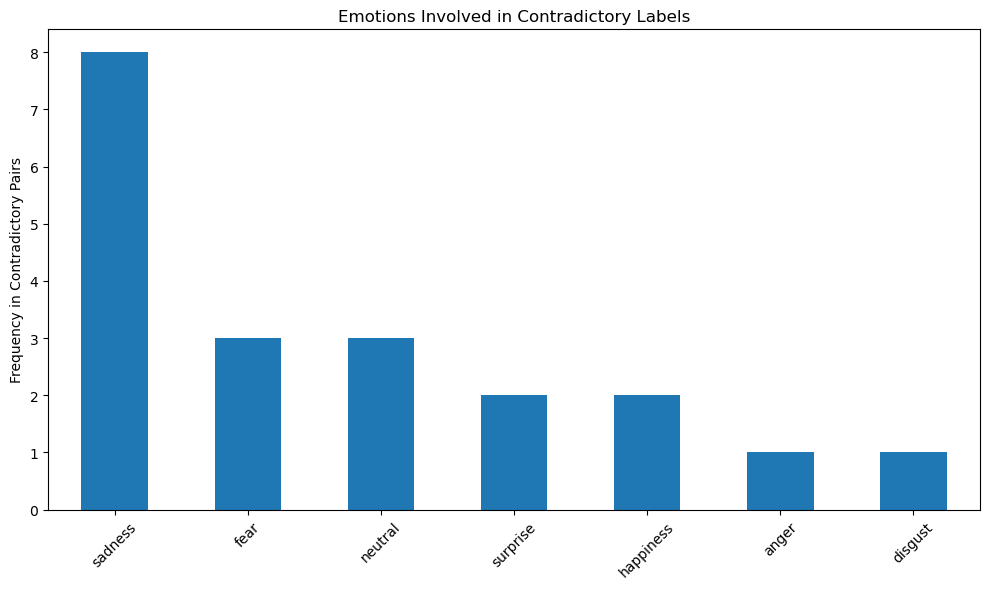

In [477]:
# Contradictory labeling patterns visualization
contradictory_emotions = []
for _, _, _, _, label1, _, label2 in near_duplicates:
    contradictory_emotions.extend([label1, label2])

contradiction_counts = pd.Series(contradictory_emotions).value_counts()
plt.figure(figsize=(10, 6))
contradiction_counts.plot(kind='bar')
plt.title('Emotions Involved in Contradictory Labels')
plt.ylabel('Frequency in Contradictory Pairs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Emotion-intensity mismatches*

In [478]:
# Get the intensity value counts for each emotion
for emotion in labels.unique():
    emotion_data = transcript[transcript['Emotion_core'] == emotion]
    intensity_dist = emotion_data['Intensity'].value_counts()
    print(f'{emotion}: {intensity_dist.to_dict()}')

neutral: {'neutral': 321, 'mild': 144, 'moderate': 7}
happiness: {'mild': 175, 'moderate': 59, 'intense': 13}
sadness: {'mild': 79, 'moderate': 76, 'intense': 9}
fear: {'moderate': 32, 'mild': 28, 'intense': 9}
anger: {'moderate': 59, 'mild': 39, 'intense': 8}
surprise: {'mild': 66, 'moderate': 37, 'intense': 4}
disgust: {'moderate': 32, 'mild': 24, 'intense': 6}


In [479]:
# Look for potentially problematic combinations of intensity and emotion
potentially_problematic = {
    'anger': transcript[(transcript['Emotion_core'] == 'anger') & (transcript['Intensity'] == 'mild')],
    'fear': transcript[(transcript['Emotion_core'] == 'fear') & (transcript['Intensity'] == 'mild')],
    'neutral': transcript[(transcript['Emotion_core'] == 'neutral') & (transcript['Intensity'] == 'intense')]
}

for emotion_intensity, data in potentially_problematic.items():
    print(f'\nPotentially unusual: {emotion_intensity} ({len(data)} cases)')
    if len(data) > 0: print('Examples:', data['Sentence'].head(5).tolist())


Potentially unusual: anger (39 cases)
Examples: ['Rude.', 'Stop it.', "No, he's not.", 'No, no.', 'Well, you brought them into a mess.']

Potentially unusual: fear (28 cases)
Examples: ["My mom and I don't know about the restaurant business,", 'Are we going to have enough bread for tonight?', "Who's going to bring the people in?", "Don't drink so much, okay?", 'before you took over?']

Potentially unusual: neutral (0 cases)


**Intensity Logic Validation:** Mild anger (39 cases) and mild fear (28 cases) match examples like “Rude” or “Don’t drink so much, okay?” The lack of intense neutral emotions shows consistent intensity-emotion pairing, supporting the dataset’s quality.

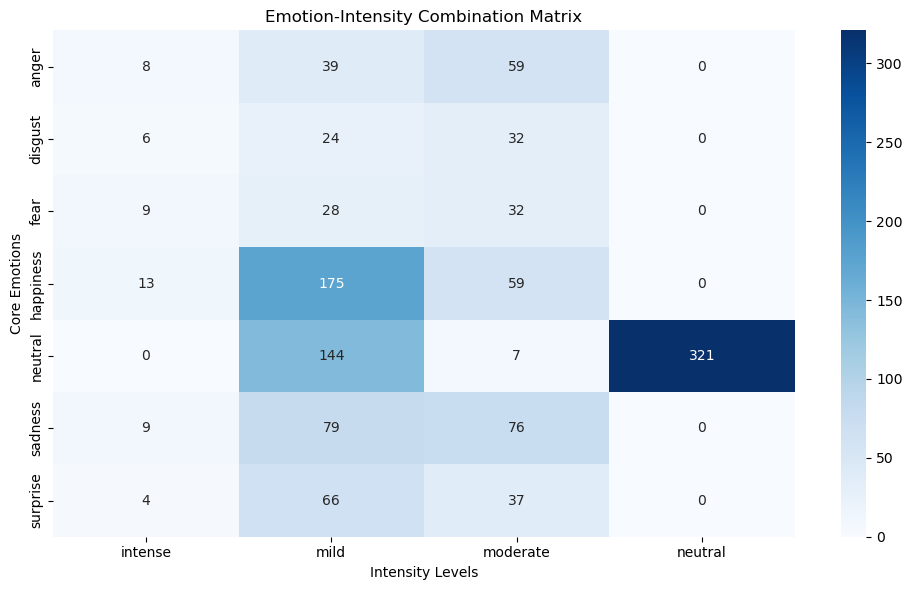

In [480]:
# Emotion-intensity heatmap visualization
emotion_intensity_matrix = pd.crosstab(transcript['Emotion_core'], transcript['Intensity'])
plt.figure(figsize=(10, 6))
sns.heatmap(emotion_intensity_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Emotion-Intensity Combination Matrix')
plt.ylabel('Core Emotions')
plt.xlabel('Intensity Levels')
plt.tight_layout()
plt.show()

### 2. Text Quality Issues
- Spelling errors
- Encoding errors
- Unusual character patterns

In [481]:
sentences = transcript['Sentence']

*Spelling errors*

In [482]:
# Use SpellChecker to look for mispelled words
spell = SpellChecker('en')

misspelled_sentences = []
all_misspelled = set()

for i, sentence in enumerate(sentences):
    words = sentence.lower().split()
    # Remove punctuation
    words = [re.sub(r'^[^\w]+|[^\w]+$', '', word) for word in words if word]
    
    # Find misspelled words
    misspelled = spell.unknown(words)
    
    if misspelled:
        misspelled_sentences.append((i, sentence, misspelled))
        all_misspelled.update(misspelled)

print(f'Sentences with potential spelling errors: {len(misspelled_sentences)}')
print(f'Unique misspelled words found: {len(all_misspelled)}')

Sentences with potential spelling errors: 268
Unique misspelled words found: 67


In [483]:
# Show examples of frequently mispelled words
misspelled_dict = {}

for _, _, misspelled in misspelled_sentences:
    for word in misspelled:
        if word in misspelled_dict:
            misspelled_dict[word] += 1
        else:
            misspelled_dict[word] = 1
most_common_misspelled = sorted(misspelled_dict.items(), key=lambda item: item[1], reverse=True)[:10]

print('Most frequent misspelled words:')
for word, count in most_common_misspelled:
    print(f'  {word}: {count} times')
    suggestions = spell.candidates(word)
    if suggestions:
        print(f'\tSuggestions: {list(suggestions)[:3]}')


Most frequent misspelled words:
  i'm: 61 times
	Suggestions: ["h'm", 'ism']
  ok: 42 times
	Suggestions: ['oik', 'on', 'wok']
  tatiana: 35 times
	Suggestions: ['patina', 'titian']
  i've: 16 times
	Suggestions: ['dive', 'give', 'wave']
  charlie's: 11 times
	Suggestions: ['charlies']
  casimiro: 10 times
  ramsay: 10 times
	Suggestions: ['rams', 'raspy', 'ramify']
  val: 8 times
	Suggestions: ['sal', 'pal', 'veal']
  italian: 6 times
	Suggestions: ['talion', 'italic', 'italics']
  di: 5 times
	Suggestions: ['dc', 'si', 'hi']


In [484]:
# Unusual patterns that could be present in the transcript
unusual_patterns = {
    'double_letters': r'(.)\1{2,}',  # 3+ repeated letters
    'mixed_case': r'[a-z][A-Z]',     # Mixed case within words
    'numbers_in_words': r'[a-zA-Z]\d|[0-9][a-zA-Z]'  # Numbers mixed with letters
}

for pattern_name, pattern in unusual_patterns.items():
    matches = sentences.str.contains(pattern)
    print(f"{pattern_name.replace('_', ' ').title()}: {matches.sum()} sentences")
    examples = sentences[matches].head(2)
    for ex in examples:
        print(f"  {ex}")

Double Letters: 2 sentences
  Probably like $1,000.
  1,000 miles away from anything called focaccia,
Mixed Case: 0 sentences
Numbers In Words: 1 sentences
  Calamari, go out on P1.


C:\Users\Erik\AppData\Local\Temp\ipykernel_34620\3665159972.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = sentences.str.contains(pattern)


**Domain-Specific "Errors":** Most "misspelled" words are proper names (Tatiana, Casimiro, Ramsay) and contractions (I'm, I've) that spell-checkers flag incorrectly. Only 268 sentences affected suggests authentic spoken language rather than genuine spelling errors, validating transcript quality for emotion detection training.

*Encoding errors*

In [485]:
# Check for sentences with non-ASCII characters
non_ascii = sentences.str.contains(r'[^\x00-\x7F]')
print(f'Sentences with non-ASCII characters: {non_ascii.sum()}')

Sentences with non-ASCII characters: 3


In [486]:
print('Examples:')
examples = sentences[non_ascii].head(3)
for i, sentence in enumerate(examples):
    print(f"  {i+1}. {sentence}")
    # Highlight the non-ASCII characters
    non_ascii_chars = [char for char in sentence if ord(char) > 127]
    if non_ascii_chars:
        print(f"     Non-ASCII chars: {set(non_ascii_chars)}")

Examples:
  1. Necesitamos enseñarlo en este.
     Non-ASCII chars: {'ñ'}
  2. No, yo sabía.
     Non-ASCII chars: {'í'}
  3. Yo sabía yo.
     Non-ASCII chars: {'í'}


**Authentic Multilingual Content:** Three Spanish sentences with accented characters (ñ, í) show multilingual communication in the kitchen. These are not errors.

*Unusual character patterns*

In [487]:
# Check for two or more consecutive whitespaces
excessive_whitespace = sentences.str.contains(r'\s{2,}')
print(f'Sentences with excessive whitespace: {excessive_whitespace.sum()}')

Sentences with excessive whitespace: 0


In [488]:
very_short = sentences.str.len() < 3
very_long = sentences.str.len() > 350
print(f'Suspiciously short sentences (<3 chars): {very_short.sum()}')
print(f'Suspiciously long sentences (>350 chars): {very_long.sum()}')

Suspiciously short sentences (<3 chars): 0
Suspiciously long sentences (>350 chars): 0


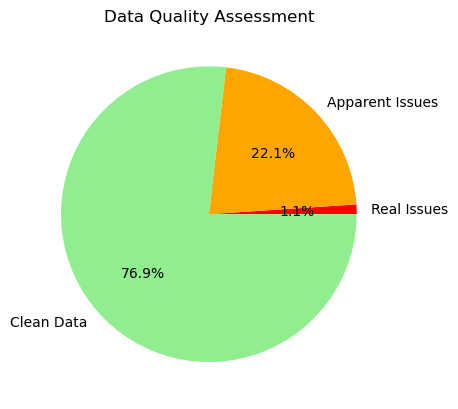

In [516]:
# Data quality visualization
quality_issues = pd.DataFrame({
    'Count': [10, 268, 3, 3, 0],
    'Severity': ['Low', 'Non-Issue', 'Expected', 'Very Low', 'None']
})

# Real vs apparent issues
real_issues = quality_issues[quality_issues['Severity'].isin(['Low', 'Very Low'])]['Count'].sum()
apparent_issues = quality_issues[~quality_issues['Severity'].isin(['Low', 'Very Low', 'None'])]['Count'].sum()

plt.pie([real_issues, apparent_issues, len(sentences)-real_issues-apparent_issues], 
        labels=['Real Issues', 'Apparent Issues', 'Clean Data'],
        colors=['red', 'orange', 'lightgreen'],
        autopct='%1.1f%%')
plt.title('Data Quality Assessment')
plt.show()

### 3. Systematic Gaps & Imbalances
- Time gaps
- Missing emotions during time periods
- Long periods without certain emotions
- Emotional progression inconsistencies

In [490]:
emotions = transcript['Emotion_core']
all_emotions = set(emotions.unique())

*Time gaps*

In [491]:
# Look for time gaps
time_gaps = []
for i in range(len(transcript)-1):
    current_end = transcript.iloc[i]['End Time']
    next_start = transcript.iloc[i+1]['Start Time']

    gap_duration = next_start - current_end
    gap_seconds = gap_duration.total_seconds()

    # Only save gaps bigger than 5 seconds
    if gap_seconds > 5:
        time_gaps.append([i, gap_seconds])

# Show the gaps
print(f'Time gaps > 5 seconds: {len(time_gaps)}')
sorted_time_gaps = sorted(time_gaps, key=lambda x: x[1], reverse=True)
for pos, gap in sorted_time_gaps:
    print(f'  Gap: {gap:.1f} seconds at position {pos}')

Time gaps > 5 seconds: 24
  Gap: 21.3 seconds at position 846
  Gap: 18.3 seconds at position 839
  Gap: 17.5 seconds at position 853
  Gap: 10.0 seconds at position 643
  Gap: 9.7 seconds at position 533
  Gap: 8.9 seconds at position 608
  Gap: 8.9 seconds at position 834
  Gap: 8.0 seconds at position 75
  Gap: 7.2 seconds at position 849
  Gap: 6.7 seconds at position 282
  Gap: 6.3 seconds at position 550
  Gap: 6.3 seconds at position 721
  Gap: 6.0 seconds at position 593
  Gap: 5.9 seconds at position 1200
  Gap: 5.9 seconds at position 547
  Gap: 5.8 seconds at position 965
  Gap: 5.7 seconds at position 575
  Gap: 5.6 seconds at position 747
  Gap: 5.5 seconds at position 847
  Gap: 5.5 seconds at position 837
  Gap: 5.4 seconds at position 870
  Gap: 5.4 seconds at position 531
  Gap: 5.3 seconds at position 633
  Gap: 5.3 seconds at position 1210


**Expected Production Gaps:** The 24 time gaps (largest 21.3 seconds) likely represent scene transitions or editing cuts typical in cooking show production. These gaps don't indicate data quality issues but authentic broadcast structure that models must handle in real deployment.

*Missing emotions during time periods*

In [ ]:
# Calculate total duration of the transcript
total_duration = transcript['Start Time'].max() - transcript['Start Time'].min()
window_size = total_duration / 10 # Divide into 10 parts

In [ ]:
# Extract all the emotions per episode window
emotions_by_window = []
for i in range(10):
    window_start = transcript['Start Time'].min() + (i * window_size)
    window_end = window_start + window_size

    window_data = transcript[
        (transcript['Start Time'] >= window_start) & 
        (transcript['Start Time'] < window_end)
    ]

    emotions_in_window = set(window_data['Emotion_core'].unique())
    emotions_by_window.append({
        'window': i+1,
        'start_time': window_start.strftime('%M:%S:%f'),
        'emotions': emotions_in_window,
        'emotion_count': len(emotions_in_window),
        'sentence_count': len(window_data)
    })

In [494]:
print('Emotion coverage by time window:')
for window_info in emotions_by_window:
    missing_emotions = all_emotions - window_info['emotions']
    print(f"Window {window_info['window']} ({window_info['start_time']}): "
          f"{window_info['emotion_count']}/{len(all_emotions)} emotions "
          f"({window_info['sentence_count']} sentences)")
    if missing_emotions:
        print(f'  Missing: {", ".join(missing_emotions)}')

Emotion coverage by time window:
Window 1 (00:00:000000): 7/7 emotions (121 sentences)
Window 2 (04:07:163598): 7/7 emotions (129 sentences)
Window 3 (08:14:327197): 7/7 emotions (138 sentences)
Window 4 (12:21:490795): 7/7 emotions (125 sentences)
Window 5 (16:28:654394): 7/7 emotions (105 sentences)
Window 6 (20:35:817993): 7/7 emotions (120 sentences)
Window 7 (24:42:981591): 7/7 emotions (109 sentences)
Window 8 (28:50:145190): 6/7 emotions (105 sentences)
  Missing: disgust
Window 9 (32:57:308788): 6/7 emotions (142 sentences)
  Missing: disgust
Window 10 (37:04:472387): 6/7 emotions (132 sentences)
  Missing: fear


**Critical Distribution Gaps:** Disgust is missing in parts 8–9 and fear in the last one.

*Long periods without certain emotions*

In [517]:
# Look for huge gaps of emotions not being present in the transcript 
for emotion in all_emotions:
    emotion_positions = transcript[transcript['Emotion_core'] == emotion].index.tolist()

    gaps = []
    for i in range (len(emotion_positions)-1):
        gap_size = emotion_positions[i+1] - emotion_positions[i] - 1
        # Only save sentences with gaps bigger than 20
        if gap_size > 20:
            gaps.append((emotion_positions[i], emotion_positions[i+1], gap_size))

    if gaps:
        print(f'\n{emotion} gap (>20 sentences without this emotion):')
        for start, end, gap_size in sorted(gaps, key=lambda x: x[2], reverse=True)[:3]:
            print(f'  {gap_size} sentences gap between positions {start} and {end}')


anger gap (>20 sentences without this emotion):
  98 sentences gap between positions 837 and 936
  87 sentences gap between positions 949 and 1037
  78 sentences gap between positions 1118 and 1197

sadness gap (>20 sentences without this emotion):
  91 sentences gap between positions 944 and 1036
  61 sentences gap between positions 882 and 944
  43 sentences gap between positions 199 and 243

disgust gap (>20 sentences without this emotion):
  264 sentences gap between positions 830 and 1095
  116 sentences gap between positions 53 and 170
  68 sentences gap between positions 623 and 692

fear gap (>20 sentences without this emotion):
  99 sentences gap between positions 914 and 1014
  63 sentences gap between positions 413 and 477
  59 sentences gap between positions 82 and 142

surprise gap (>20 sentences without this emotion):
  67 sentences gap between positions 779 and 847
  60 sentences gap between positions 684 and 745
  54 sentences gap between positions 561 and 616

happine

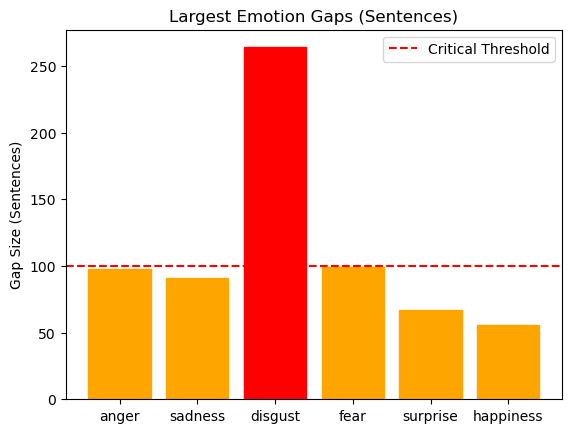

In [518]:
# Gap analysis visualization (manual inputs)
dataset_length = len(sentences)
gap_data = pd.DataFrame({
    'Emotion': ['anger', 'sadness', 'disgust', 'fear', 'surprise', 'happiness'],
    'Largest Gap': [98, 91, 264, 99, 67, 56],
    'Gap Percentage': [98/dataset_length*100,
                       91/dataset_length*100,
                       264/dataset_length*100,
                       99/dataset_length*100,
                       67/dataset_length*100,
                       56/dataset_length*100
                    ]
})

# Gap sizes
bars = plt.bar(gap_data['Emotion'], gap_data['Largest Gap'])
plt.title('Largest Emotion Gaps (Sentences)')
plt.ylabel('Gap Size (Sentences)')
plt.axhline(y=100, color='red', linestyle='--', label='Critical Threshold')
plt.legend()

# Highlight critical gaps
for i, (bar, gap) in enumerate(zip(bars, gap_data['Largest Gap'])):
    color = 'red' if gap > 100 else 'orange' if gap > 50 else 'green'
    bar.set_color(color)

plt.show()

**Critical Distribution Gaps:** The 264-sentence gap for disgust (21.5% of the dataset) highlights a significant training data deficiency.

*Emotional progression inconsistencies*

In [ ]:
# Possible opposite combinations of core emotions
opposites = {
    ('happiness', 'sadness'), ('sadness', 'happiness'),
    ('happiness', 'anger'), ('anger', 'happiness'),
    ('happiness', 'fear'), ('fear', 'happiness'),
    ('neutral', 'anger'), ('anger', 'neutral'),
    ('surprise', 'sadness'), ('sadness', 'surprise')
}

In [497]:
window = 3
inconsistencies = []
emotions_list = emotions.tolist()
seen_pairs = set()

# Iterate through the emotions list with the lookback window of 3
for i in range(len(emotions_list) - window + 1):
    window_emotions = emotions_list[i:i+window]
    for j in range(len(window_emotions) - 1):
        pair = (window_emotions[j], window_emotions[j+1])
        # Save if the pair is a possible opposite
        if pair in opposites and pair not in seen_pairs:
            inconsistencies.append((i+j, window_emotions[j], window_emotions[j+1]))
            seen_pairs.add(pair)

print(f'Inconsistencies of emotions found: {len(inconsistencies)}')
if inconsistencies:
    print('Examples:')
    for i, (pos, from_emotion, to_emotion) in enumerate(inconsistencies[:5]):
        print(f'  Position {pos}: {from_emotion} -> {to_emotion}')
        print(f'\tContext: {transcript.iloc[pos]["Sentence"]}')
        print(f'\t\t{transcript.iloc[pos+1]["Sentence"]}')


Inconsistencies of emotions found: 10
Examples:
  Position 7: happiness -> sadness
	Context: And then I had the opportunity to take it over,
		but I didn't have the money or the collateral,
  Position 11: fear -> happiness
	Context: finance the restaurant and put their houses up as collateral
		to help Tatiana fulfill her dream.
  Position 12: happiness -> fear
	Context: to help Tatiana fulfill her dream.
		My mom and I don't know about the restaurant business,
  Position 29: anger -> neutral
	Context: That doesn't even pay for the costs
		of just running electricity.
  Position 32: neutral -> anger
	Context: I don't know.
		The problem with the restaurant is Tatiana.


**Overall Quality Assessment:** The dataset is high quality, with few errors (0.8% contradictory labels) and authentic cooking show content. The main issue is emotion gaps, especially underrepresented disgust, which should be addressed while keeping the dataset’s natural language patterns.

---

## 5. Reflection for Training Data Selection

### **Critical Training Data Requirements**

**Emotion Balance Priority:** Our analysis reveals class imbalance with disgust (5.1%) and fear (5.6%), while neutral (38.5%) dominates. Training data must oversample negative emotions to prevent model bias toward neutral classifications.

**Domain-Specific Language Preservation:** The 35.4% contraction rate, 10.7% filler usage, and 32.4% command-style sentences represent authentic cooking show communication. Training data should maintain these proportions rather than using formal written text.

### **Pre-Existing Datasets**

**For Emotion Balance:**
- **IEMOCAP:** Provides balanced emotion distribution with sufficient disgust/fear samples to address our critical gaps.
- **EmoReact:** Contains natural emotional reactions including disgust responses that can supplement our missing 264-sentence gap.

**For Domain Language:**
- **YouCook2:** ASR-transcribed cooking videos matching our informal speech patterns and cooking vocabulary.
- **Common Voice (English cooking queries):** Maintains authentic speech artifacts like contractions and fillers.

**For ASR Characteristics:**
- **LibriSpeech:** Contains natural speech disfluencies and transcription patterns similar to our AssemblyAI output.

### **Implementation Strategy**

**Approach:** Use our test set's characteristics as quality filters - select training samples that match our 26.7-character average sentences and temporal emotion patterns. Discard overly formal or artificially cleaned text that differentiates from our patterns.

**Quality Validation:** Our test set serves as the standard for domain authenticity - any training data that significantly differs from our established patterns (sentence length, emotion distributions, informal speech characteristics) should be excluded to prevent mismatch.